# 📊 AI-Driven Investment Analysis: Apple vs Intel

## Introduction

This project aims to analyze and compare the financial performance of two major technology companies, Apple Inc. and Intel Corporation, using data sourced from WRDS (Compustat).

The objective is to develop a Python-based analytical workflow to support investment decision-making, specifically identifying a potential long-short strategy based on financial performance.

## Objective

The main objectives of this project are:

- To analyze revenue and profitability trends of Apple and Intel
- To compare financial performance using key metrics such as revenue, net income, and total assets
- To derive investment insights and propose a long-short strategy

## Data Source

The data used in this project is obtained from WRDS (Wharton Research Data Services), specifically from the Compustat North America Fundamentals Quarterly database.

Quarterly data is used to provide more detailed and higher-frequency insights into company performance trends.

Key variables include:

- Revenue (revtq)
- Net Income (niq)
- Total Assets (atq)
- Data Date (datadate)

## Methodology

The analysis is conducted using Python, primarily leveraging the pandas and matplotlib libraries.

The workflow includes:

1. Data extraction from WRDS
2. Data cleaning and preprocessing
3. Financial trend analysis through visualization
4. Comparative analysis between the two firms
5. Investment conclusion based on observed performance
Additionally, quarterly data is transformed into time-series format to ensure comparability between companies with different fiscal reporting periods.

In [7]:
import pandas as pd

data = pd.read_csv("AAPL_INTC_quarterly.csv")

print(data.head())

  costat curcdq datafmt indfmt consol   tic    datadate  gvkey       atq  \
0      A    USD     STD   INDL      C  AAPL  2015-03-31   1690  261194.0   
1      A    USD     STD   INDL      C  AAPL  2015-06-30   1690  273151.0   
2      A    USD     STD   INDL      C  AAPL  2015-09-30   1690  290479.0   
3      A    USD     STD   INDL      C  AAPL  2015-12-31   1690  293284.0   
4      A    USD     STD   INDL      C  AAPL  2016-03-31   1690  305277.0   

       niq    revtq  
0  13569.0  58010.0  
1  10677.0  49605.0  
2  11124.0  51501.0  
3  18361.0  75324.0  
4  10516.0  50557.0  


In [8]:
apple = data[data['tic'] == 'AAPL']
intel = data[data['tic'] == 'INTC']
data['datadate'] = pd.to_datetime(data['datadate'])

apple = data[data['tic'] == 'AAPL'].sort_values('datadate')
intel = data[data['tic'] == 'INTC'].sort_values('datadate')

In [9]:
data['datadate'] = pd.to_datetime(data['datadate'])

apple = apple.sort_values('datadate')
intel = intel.sort_values('datadate')

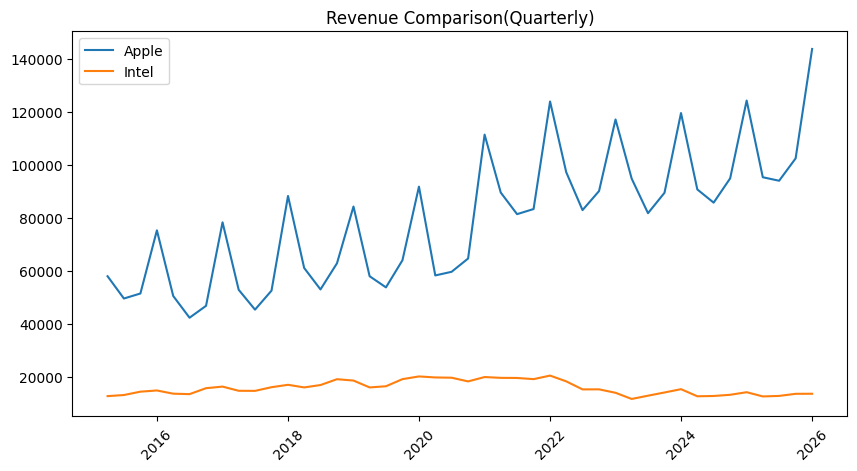

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(apple['datadate'], apple['revtq'], label='Apple')
plt.plot(intel['datadate'], intel['revtq'], label='Intel')

plt.legend()
plt.title("Revenue Comparison(Quarterly)")
plt.xticks(rotation=45)
plt.show()

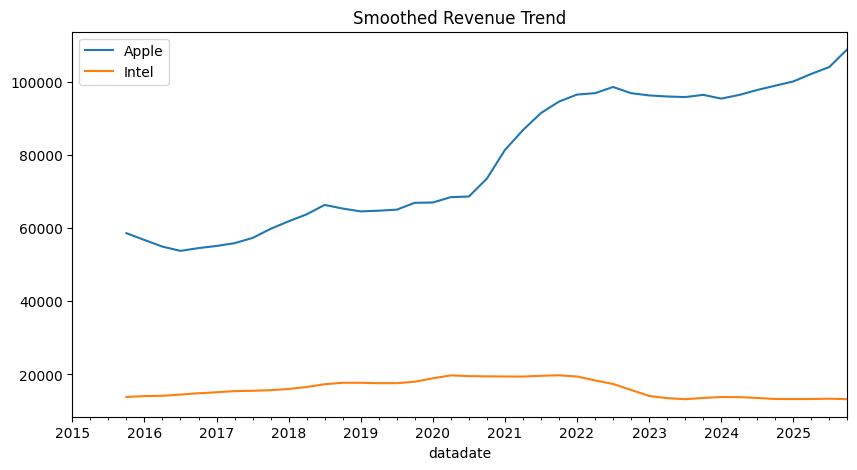

In [11]:
comparison = pd.concat([
    apple.set_index('datadate')['revtq'],
    intel.set_index('datadate')['revtq']
], axis=1)

comparison.columns = ['Apple', 'Intel']

comparison_ma = comparison.rolling(4).mean()

comparison_ma.plot(figsize=(10,5), title="Smoothed Revenue Trend")
plt.show()

### Revenue Analysis

Quarterly revenue exhibits seasonal fluctuations, particularly for Apple due to product release cycles and holiday demand.

Apple demonstrates a consistent upward trend in revenue, indicating strong growth and market demand.

In contrast, Intel shows relatively stagnant revenue over time, suggesting limited growth potential and weaker competitive positioning.

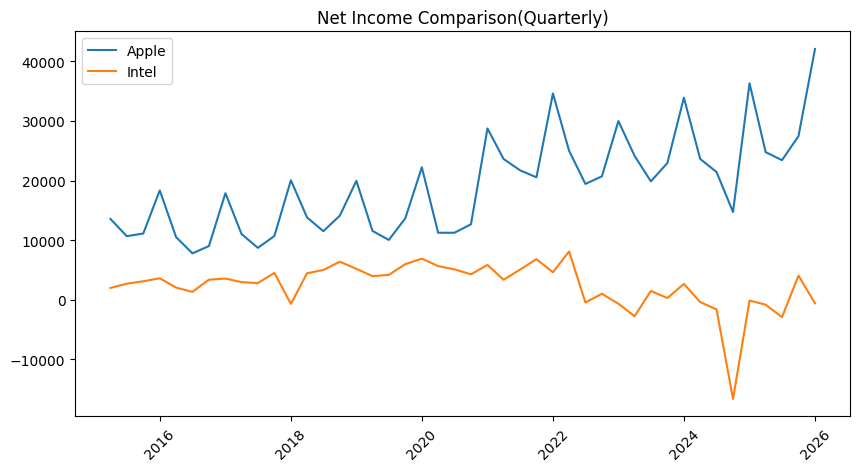

In [12]:
plt.figure(figsize=(10,5))
plt.plot(apple['datadate'], apple['niq'], label='Apple')
plt.plot(intel['datadate'], intel['niq'], label='Intel')

plt.legend()
plt.title("Net Income Comparison(Quarterly)")
plt.xticks(rotation=45)
plt.show()

### Net Income Analysis

Apple maintains strong and stable profitability throughout the period, reflecting efficient operations and strong pricing power.

Intel, however, exhibits declining net income and even negative values in recent periods, indicating financial instability and operational challenges.

## Investment Conclusion

Based on the analysis:

- Apple is identified as a strong long position due to its consistent revenue growth, strong profitability, and stable financial performance.
- Intel is considered a short position due to its declining profitability, weaker growth outlook, and financial instability.

This long-short strategy highlights the divergence in fundamentals between the two firms.